<a href="https://colab.research.google.com/github/Code-blize/Code-blize/blob/main/Computer_Vision_Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Text Recognition using OCR (Optical Character Recognition)


In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import pytesseract
import openpyxl
import os
import glob
import easyocr
import re

# Download dataset
path = kagglehub.dataset_download("urbikn/sroie-datasetv2")

print("Path to dataset files:", path)

for root, dirs, files in os.walk(path):
  print(root)
  print(len(files), "files")
  break

Using Colab cache for faster access to the 'sroie-datasetv2' dataset.
Path to dataset files: /kaggle/input/sroie-datasetv2
/kaggle/input/sroie-datasetv2
0 files


Total images: 973


(np.float64(-0.5), np.float64(2480.5), np.float64(3507.5), np.float64(-0.5))

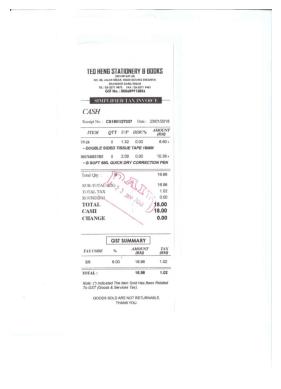

In [ ]:
# find images
images = glob.glob(path + "/**/*.jpg", recursive=True)
print("Total images:", len(images))
img = cv2.imread(images[972])
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

## Convert to Grayscale

- Removes unnecessary color
- Emphasizes text contrast
- Simplifies the data from 3 channels to 1 channels

(np.float64(-0.5), np.float64(2480.5), np.float64(3507.5), np.float64(-0.5))

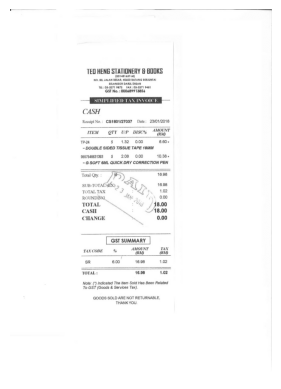

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap="gray")
plt.axis("off")

## Applying Thresholding  

-Making the text to stand out

(np.float64(-0.5), np.float64(2480.5), np.float64(3507.5), np.float64(-0.5))

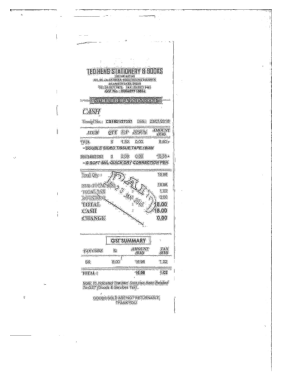

In [ ]:
thresh = cv2.adaptiveThreshold(gray,
                       255,
                       cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                       cv2.THRESH_BINARY,
                       11, 2
                       )
plt.imshow(thresh, cmap="gray")
plt.axis("off")

In [ ]:
reader = easyocr.Reader(['en'])

results = reader.readtext(thresh)
for r in results:
  print(r[1])

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Te NENg statInerv E bddks
[0p14512274w
iNOa52; JALANIESAR 45400,0ATANTQERiutai
#SELANAZRRARWWEHBAN
{uk0353271,0072TzZ
0313271,541:
GST No;7000682913856'
{WitmCiD
NVOI6m
CASH
'Receipl Nowz 'CS180 1/27037
I@are;
231012018
64n
HTEN;
@FT
@FL
DISC%
AMOUNT;
(RV
06lt7a~
led
7FS2A 
5
432;
"'Ojool:
BJ808
'DovBLE gided tissue WaEIAMM
{9557546630393]
208
'@@@}
'10,38 #
~QISQFTOMLIQuicK DRyy corReCTIQN PEN:
Total
181982
JSUB-TOTAE
46,98,
"TOTALTX
102
R@UNDNG
"0.00}|
TTOTAL;
718 @i
CASH
'18,@0:
CTIANGE
I0.00
0l
CST SUMMARY
TAX CODE
pa
EAMOUNT'
MAXi 
{EV)
{RAI
3
3R1
"Gi0Q:"
446.98
7102
TorAL
"18198
402,
Notes_
Indlcatediglelltem Sold Fias Beer Rejeted?'
To GST (Goods & Seryices Tax),
'GOQDS SOLD ARENOTRETURNABLE}
TTHANK YoU
Qty:e
2di;


Makek the OCR readable

In [ ]:
def draw_easyocr_boxes(image_bgr, results):
  img = image_bgr.copy()
  for (box, text, conf) in results:
    pts = np.array(box, dtype=np.int32)
    cv2.polylines(img, [pts], isClosed=True, color=(0, 255, 0), thickness=2)
    x, y = pts[0]
    cv2.putText(img, f"{text} ({conf:2f})", (x, y-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1, cv2.LINE_AA)
    return img

    boxed = draw_easyocr_boxes(img, results)
    plt.figure(figsize=(12, 12))
    plt.imshow(cv2.cvtColor(boxed, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()


sort detected text into reading order

In [ ]:
def y_center(box):
  ys = [p[1] for p in box]
  return sum(ys)/len(ys)

def x_center(box):
  xs = [p[0] for p in box]
  return sum(xs)/len(xs)

# sort by y then x
sorted_results = sorted(results, key=lambda r: (y_center(r[0]), x_center(r[0])))

for box, text, conf in sorted_results:
  if conf > 0.25:
     print(text)


GST No;7000682913856'
CASH
231012018
AMOUNT;
HTEN;
(RV
5
208
{9557546630393]
181982
Total
102
"TOTALTX
R@UNDNG
'18,@0:
CASH
I0.00
CTIANGE
CST SUMMARY
TAX CODE
{EV)
3
446.98
7102
"18198
To GST (Goods & Seryices Tax),
TTHANK YoU


Extract Date and Total using rules

In [ ]:
full_text = "\n".join([t for _, t, _ in sorted_results])

# date patterns
date_march = re.search(r'(\d{2}[\/\-]\d{2}[\/\-]\d{4})', full_text)

# total patterns
total_march = re.search(r'(?:Total|TOTAL)\s*(?:RM)?\s*([0-9]+(?:\.[0-9]{2})?)', full_text, re.IGNORECASE)

print("Extracted Date:", date_march.group(1) if date_march else None)
print("Extracted Total:", total_march.group(1) if total_march else None)

Extracted Date: None
Extracted Total: None


In [ ]:
def show(img, title="image", size=8):
    plt.figure(figsize=(size, size))

    # If grayscale
    if len(img.shape) == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    plt.title(title)
    plt.axis("off")
    plt.show()

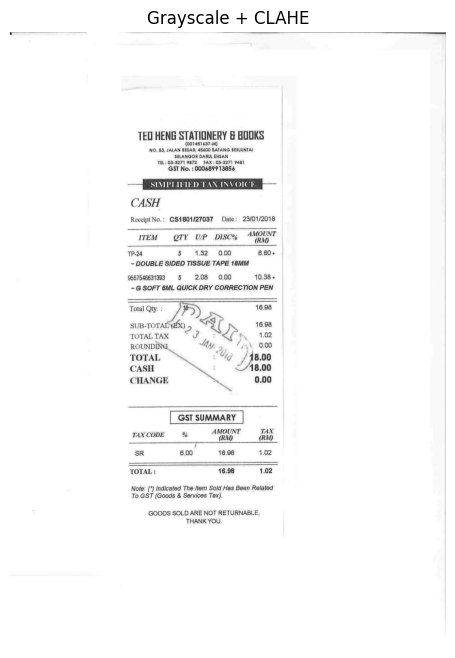

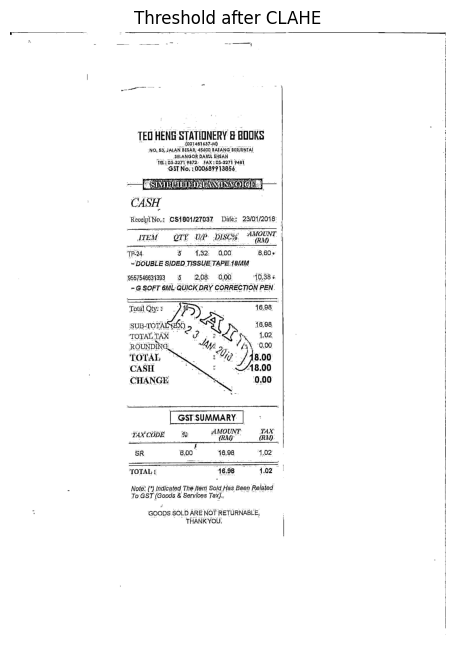

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# increase contrast
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
gray2 = clahe.apply(gray)

thresh2 = cv2.adaptiveThreshold(
    gray2, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    31,  # bigger window helps receipts
    10
)

show(gray2, "Grayscale + CLAHE")
show(thresh2, "Threshold after CLAHE")

(np.float64(-0.5), np.float64(2480.5), np.float64(3507.5), np.float64(-0.5))

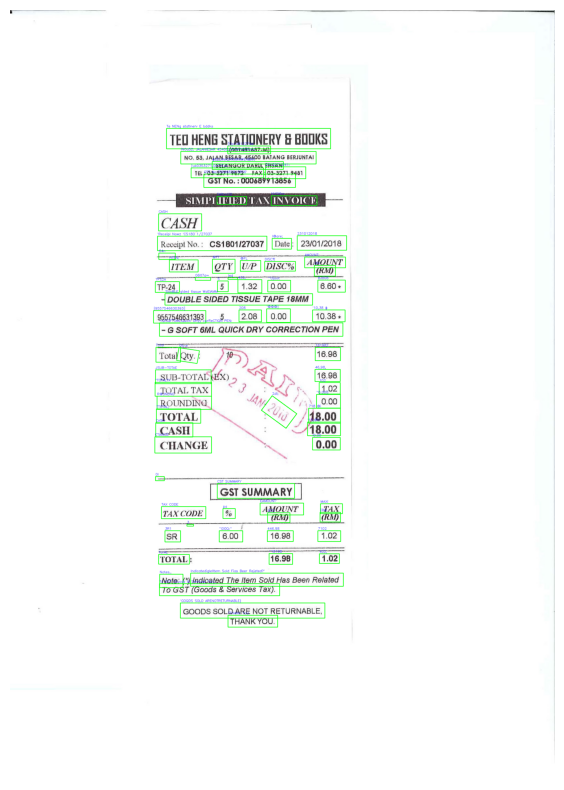

In [ ]:
img_copy = img.copy()

for (bbox, text, prob) in results:
    pts = np.array(bbox).astype(int)

    cv2.polylines(img_copy, [pts], True, (0,255,0), 2)

    x, y = pts[0]
    cv2.putText(img_copy, text, (x, y-5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5, (255,0,0), 1)

plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
plt.axis("off")

In [ ]:
def y_center(box):
    ys = [p[1] for p in box]
    return sum(ys)/len(ys)

def x_center(box):
    xs = [p[0] for p in box]
    return sum(xs)/len(xs)

def extract_total_from_easyocr(results):
    # Sort in reading order
    sorted_res = sorted(results, key=lambda r: (y_center(r[0]), x_center(r[0])))

    # Keep decent-confidence text and normalize spacing
    texts = []
    for box, text, conf in sorted_res:
        if conf >= 0.25:
            cleaned = text.strip()
            if cleaned:
                texts.append(cleaned)

    full_text = "\n".join(texts)

    # Look for lines containing total keywords
    total_keywords = ["total", "grand total", "amount due", "balance", "payable"]
    lines = full_text.split("\n")

    candidate_lines = [ln for ln in lines if any(k in ln.lower() for k in total_keywords)]

    # Extract numbers from candidates; prefer the last number on the line (often the amount)
    def parse_amount(line):
        # match 42, 42.00, 1,250.50 etc.
        nums = re.findall(r'\b\d{1,3}(?:,\d{3})*(?:\.\d{2})?\b', line)
        if not nums:
            return None
        # take the last number as the likely total
        val = nums[-1].replace(",", "")
        return float(val)

    for ln in reversed(candidate_lines):  # bottom of receipt often contains total
        amt = parse_amount(ln)
        if amt is not None:
            return amt, ln

    # fallback: search the entire text for "total" followed by a number
    m = re.search(r'(?:total|grand total|amount due|balance|payable)\D{0,10}(\d{1,3}(?:,\d{3})*(?:\.\d{2})?)',
                  full_text, re.IGNORECASE)
    if m:
        return float(m.group(1).replace(",", "")), m.group(0)

    return None, None

total_value, total_line = extract_total_from_easyocr(results)
print("TOTAL:", total_value)
print("Matched line:", total_line)

TOTAL: 102.0
Matched line: Total
102


In [ ]:
def group_into_lines(results, y_tol=12, conf_min=0.25):
    # Keep good results
    items = []
    for box, text, conf in results:
        if conf >= conf_min and text.strip():
            ys = [p[1] for p in box]
            xs = [p[0] for p in box]
            items.append({
                "box": box,
                "text": text.strip(),
                "y": float(np.mean(ys)),
                "x": float(np.mean(xs))
            })
    # Sort by y then x
    items.sort(key=lambda d: (d["y"], d["x"]))

    lines = []
    for it in items:
        placed = False
        for line in lines:
            if abs(it["y"] - line["y"]) <= y_tol:
                line["words"].append(it)
                # update average y of the line
                line["y"] = float(np.mean([w["y"] for w in line["words"]]))
                placed = True
                break
        if not placed:
            lines.append({"y": it["y"], "words": [it]})

    # Sort words in each line left-to-right and join
    joined_lines = []
    for line in lines:
        line["words"].sort(key=lambda w: w["x"])
        joined_lines.append(" ".join([w["text"] for w in line["words"]]))

    return joined_lines

lines = group_into_lines(results, y_tol=12, conf_min=0.25)
print("Sample lines:")
for ln in lines[-15:]:
    print(ln)

Sample lines:
5
{9557546630393] 208
Total 181982
"TOTALTX 102
R@UNDNG
CASH '18,@0:
CTIANGE I0.00
CST SUMMARY
TAX CODE
{EV)
3
446.98 7102
"18198
To GST (Goods & Seryices Tax),
TTHANK YoU


In [ ]:
def extract_total_from_lines(lines):
    keywords = ["grand total", "total", "amount due", "balance", "payable"]
    def parse_amount(line):
        nums = re.findall(r'\b\d{1,3}(?:,\d{3})*(?:\.\d{2})?\b', line)
        if not nums:
            return None
        return float(nums[-1].replace(",", ""))

    # search from bottom upward (totals are near the bottom)
    for ln in reversed(lines):
        low = ln.lower()
        if any(k in low for k in keywords):
            amt = parse_amount(ln)
            if amt is not None:
                return amt, ln
    return None, None

total2, line2 = extract_total_from_lines(lines)
print("TOTAL:", total2)
print("Matched line:", line2)

TOTAL: 102.0
Matched line: "TOTALTX 102


In [ ]:
def extract_date_from_lines(lines):
    # common date formats: 04/01/2018, 04-01-2018, 2018/01/04 etc.
    date_patterns = [
        r'\b\d{2}[\/\-]\d{2}[\/\-]\d{4}\b',
        r'\b\d{4}[\/\-]\d{2}[\/\-]\d{2}\b'
    ]
    for ln in lines:
        low = ln.lower()
        if "date" in low:  # prioritize lines that contain the word DATE
            for pat in date_patterns:
                m = re.search(pat, ln)
                if m:
                    return m.group(0), ln

    # fallback: find the first date anywhere
    for ln in lines:
        for pat in date_patterns:
            m = re.search(pat, ln)
            if m:
                return m.group(0), ln

    return None, None

date_val, date_line = extract_date_from_lines(lines)
print("DATE:", date_val)
print("Matched line:", date_line)

DATE: None
Matched line: None


In [ ]:
def extract_merchant_from_lines(lines, top_n=15):
    top_lines = lines[:top_n]

    def score(line):
        l = line.strip()
        if len(l) < 4:
            return -999

        # ignore obvious non-merchant lines
        blacklist = ["invoice", "receipt", "tax", "gst", "date", "cash", "change", "summary", "total"]
        if any(b in l.lower() for b in blacklist):
            return -50

        # ignore lines with too many digits (phones/ids)
        digit_ratio = sum(ch.isdigit() for ch in l) / max(len(l), 1)
        if digit_ratio > 0.25:
            return -20

        # reward uppercase-heavy lines (merchants often are)
        letters = [ch for ch in l if ch.isalpha()]
        if letters:
            upper_ratio = sum(ch.isupper() for ch in letters) / len(letters)
        else:
            upper_ratio = 0

        # reward longer, “name-like” lines
        s = 0
        s += len(l) * 0.2
        s += upper_ratio * 10

        # small penalty if it looks like an address
        if re.search(r'\b(jalan|road|st|street|ave|avenue|no\.|no|bandar)\b', l.lower()):
            s -= 3

        return s

    best = max(top_lines, key=score)
    return best

merchant = extract_merchant_from_lines(lines)
print("MERCHANT:", merchant)

MERCHANT: CTIANGE I0.00


In [ ]:
def clean_merchant(text):
    t = text.upper()
    # keep letters/numbers/basic punctuation that may matter
    t = re.sub(r"[^A-Z0-9 &\-]", " ", t)   # remove weird symbols like _ ; '
    t = re.sub(r"\s+", " ", t).strip()    # collapse extra spaces
    return t

cleaned_merchant = clean_merchant(merchant)
print("CLEAN MERCHANT:", cleaned_merchant)

CLEAN MERCHANT: CTIANGE I0 00


In [ ]:
import re

def fix_common_ocr_errors(text):
    # only apply on uppercase strings
    t = text.upper()

    # common confusions in receipt OCR
    replacements = {
        "DEIIGHTS": "DELIGHTS",
        "BAK KR": "BAK KUT",   # optional if your dataset often has this
    }

    # replace whole-word occurrences
    for wrong, right in replacements.items():
        t = re.sub(rf"\b{re.escape(wrong)}\b", right, t)

    return t

fixed_merchant = fix_common_ocr_errors(cleaned_merchant)
print("FIXED MERCHANT:", fixed_merchant)

FIXED MERCHANT: CTIANGE I0 00


In [ ]:
print("Total images:", len(images))

Total images: 973


In [ ]:
import cv2, re, numpy as np
import easyocr

# If you enabled GPU in Colab, change gpu=True
reader = easyocr.Reader(['en'], gpu=False)

def preprocess_receipt(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray2 = clahe.apply(gray)
    thr = cv2.adaptiveThreshold(
        gray2, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31, 10
    )
    return thr

def group_into_lines(results, y_tol=12, conf_min=0.25):
    items = []
    for box, text, conf in results:
        if conf >= conf_min and text.strip():
            ys = [p[1] for p in box]
            xs = [p[0] for p in box]
            items.append({
                "text": text.strip(),
                "y": float(np.mean(ys)),
                "x": float(np.mean(xs))
            })

    items.sort(key=lambda d: (d["y"], d["x"]))

    lines = []
    for it in items:
        placed = False
        for line in lines:
            if abs(it["y"] - line["y"]) <= y_tol:
                line["words"].append(it)
                line["y"] = float(np.mean([w["y"] for w in line["words"]]))
                placed = True
                break
        if not placed:
            lines.append({"y": it["y"], "words": [it]})

    joined = []
    for line in lines:
        line["words"].sort(key=lambda w: w["x"])
        joined.append(" ".join([w["text"] for w in line["words"]]))
    return joined

def extract_total(lines):
    keywords = ["grand total", "total", "amount due", "balance", "payable"]

    def parse_amount(line):
        nums = re.findall(r'\b\d{1,3}(?:,\d{3})*(?:\.\d{2})?\b', line)
        if not nums:
            return None
        return float(nums[-1].replace(",", ""))

    for ln in reversed(lines):
        if any(k in ln.lower() for k in keywords):
            amt = parse_amount(ln)
            if amt is not None:
                return amt, ln
    return None, None

def extract_date(lines):
    patterns = [
        r'\b\d{2}[\/\-]\d{2}[\/\-]\d{4}\b',
        r'\b\d{4}[\/\-]\d{2}[\/\-]\d{2}\b'
    ]

    for ln in lines:
        if "date" in ln.lower():
            for p in patterns:
                m = re.search(p, ln)
                if m:
                    return m.group(0), ln

    for ln in lines:
        for p in patterns:
            m = re.search(p, ln)
            if m:
                return m.group(0), ln

    return None, None

def clean_merchant(text):
    if text is None:
        return None
    t = text.upper()
    t = re.sub(r"[^A-Z0-9 &\-]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

def extract_merchant(lines, top_n=15):
    top = lines[:top_n]
    if not top:
        return None

    blacklist = ["invoice", "receipt", "tax", "gst", "date", "cash", "change", "summary", "total"]

    def score(s):
        s = s.strip()
        if len(s) < 4:
            return -999
        if any(b in s.lower() for b in blacklist):
            return -50
        digit_ratio = sum(ch.isdigit() for ch in s) / max(len(s), 1)
        if digit_ratio > 0.25:
            return -20
        letters = [ch for ch in s if ch.isalpha()]
        upper_ratio = (sum(ch.isupper() for ch in letters) / len(letters)) if letters else 0
        sc = len(s) * 0.2 + upper_ratio * 10
        # small penalty for address-like lines
        if re.search(r'\b(jalan|road|st|street|ave|avenue|no\.|no|bandar)\b', s.lower()):
            sc -= 3
        return sc

    best = max(top, key=score)
    return clean_merchant(best)

def parse_receipt(img_bgr):
    thr = preprocess_receipt(img_bgr)
    results = reader.readtext(thr)
    lines = group_into_lines(results)

    total, total_line = extract_total(lines)
    date, date_line = extract_date(lines)
    merchant = extract_merchant(lines)

    return {
        "merchant": merchant,
        "date": date,
        "total": total,
        "total_line": total_line,
        "date_line": date_line
    }


In [ ]:
N = 30
rows = []

for img_path in images[:N]:
    img = cv2.imread(img_path)
    if img is None:
        continue
    out = parse_receipt(img)
    out["image"] = os.path.basename(img_path)
    rows.append(out)

df = pd.DataFrame(rows)
df.head()

,merchant,date,total,total_line,date_line,image
0,HENG KEE DEIISHTS BAK KTJT TEH,04/01/2018,42.0,Total: RM 42.00,DATE: 04/01/2018 7 : 42:10 AM,X51005719889.jpg
1,MEDAN NIAGA TASIK DAMAI,14/02/2018,45.0,"Total Includes GST 0% 1,45",14/02/2018 5.37:44PM,X51005447859.jpg
2,4Z100 KLANG SELANGOR,None,NaN,None,None,X51006619863.jpg
3,SECURITY & OATRADING,None,NaN,None,None,X51006619784.jpg
4,42100 KLANG SELANGOR,None,NaN,None,None,X51006733495.jpg


In [ ]:
df.to_csv("receipt_predictions.csv", index=False)
print("Saved receipt_predictions.csv")

Saved receipt_predictions.csv
